# 05 – EC3D Fine-tuning (NO UNKNOWN) - Paper-Aligned

**Versione paper-aligned**: Esclude la classe Unknown (11 classi invece di 12).

## Esperimenti:
1. **Linear Probe**: Encoder congelato + classificatore lineare
2. **MLP Probe**: Encoder congelato + MLP a 2 layer
3. **Fine-tuning**: Encoder trainabile + classificatore
4. **From Scratch**: Encoder inizializzato random + classificatore

In [22]:
# === CONFIG: NO_UNKNOWN VERSION ===
USE_NO_UNKNOWN = True
N_CLASSES = 11
RESULTS_SUBDIR = 'NO_UNKNOWN'

import sys
from pathlib import Path
import pickle
import json
import copy
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix, f1_score, top_k_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

ROOT_DIR = Path('..').resolve()
sys.path.insert(0, str(ROOT_DIR))

from models.pose_encoder.twostream_stgcn_plus import TwoStreamSTGCNPlusEncoder
from utils import load_ec3d

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cuda


In [23]:
# === Load Data ===
DATA_DIR = ROOT_DIR / 'data' / 'EC3D'
LOGS_DIR = ROOT_DIR / 'logs'
RESULTS_DIR = ROOT_DIR / 'results' / 'ec3d' / RESULTS_SUBDIR
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ec3d_data = load_ec3d(DATA_DIR, no_unknown=USE_NO_UNKNOWN)

sequences = ec3d_data['sequences']
labels = ec3d_data['labels']
train_indices = ec3d_data['train_indices']
test_indices = ec3d_data['test_indices']
ID_TO_NAME = ec3d_data['id_to_name']
NUM_CLASSES = ec3d_data['num_classes']

print(f'Totale sequenze: {len(sequences)}')
print(f'Train: {len(train_indices)}, Test: {len(test_indices)}')
print(f'Numero classi: {NUM_CLASSES}')

Totale sequenze: 362
Train: 274, Test: 88
Numero classi: 11


In [24]:
class EC3DDataset(Dataset):
    """
    Dataset PyTorch per EC3D.
    
    Trasforma le sequenze da (T, 3, 25) a (T, 25, 3) e applica padding.
    """
    def __init__(self, sequences, labels, indices, max_len=None):
        self.sequences = [sequences[i] for i in indices]
        self.labels = labels[indices]
        
        # Calcola max_len se non specificato
        if max_len is None:
            self.max_len = max(seq.shape[0] for seq in self.sequences)
        else:
            self.max_len = max_len
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]  # (T, 3, 25)
        label = self.labels[idx]
        
        # Trasposizione: (T, 3, 25) -> (T, 25, 3)
        seq = np.transpose(seq, (0, 2, 1))  # (T, 25, 3)
        
        T, V, C = seq.shape
        
        # Padding a max_len
        if T < self.max_len:
            pad = np.zeros((self.max_len - T, V, C), dtype=np.float32)
            seq = np.concatenate([seq, pad], axis=0)
        elif T > self.max_len:
            # Truncate (sampling uniforme)
            indices = np.linspace(0, T - 1, self.max_len).astype(int)
            seq = seq[indices]
        
        seq = torch.from_numpy(seq.astype(np.float32))
        label = torch.tensor(label, dtype=torch.long)
        
        return seq, label


# Analisi lunghezze sequenze
seq_lengths = [seq.shape[0] for seq in sequences]
print(f"Lunghezza min: {min(seq_lengths)}, max: {max(seq_lengths)}, media: {np.mean(seq_lengths):.1f}")

# Usa una lunghezza fissa ragionevole
MAX_LEN = 150  # Copre la maggior parte delle sequenze
BATCH_SIZE = 16

# Crea dataset
train_dataset = EC3DDataset(sequences, labels, train_indices, max_len=MAX_LEN)
test_dataset = EC3DDataset(sequences, labels, test_indices, max_len=MAX_LEN)

# Crea DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n✅ Dataset creati:")
print(f"   Train: {len(train_dataset)} sequenze, {len(train_loader)} batch")
print(f"   Test: {len(test_dataset)} sequenze, {len(test_loader)} batch")

# Test
sample_seq, sample_label = train_dataset[0]
print(f"   Shape sequenza: {sample_seq.shape}")
print(f"   Label: {sample_label.item()} ({ID_TO_NAME[sample_label.item()]})")


Lunghezza min: 24, max: 208, media: 80.0

✅ Dataset creati:
   Train: 274 sequenze, 18 batch
   Test: 88 sequenze, 6 batch
   Shape sequenza: torch.Size([150, 25, 3])
   Label: 5 (LUNGES - Correct)


In [25]:
# Carica il checkpoint migliore (epoch 30)
BEST_EPOCH = 30
CHECKPOINT_PATH = LOGS_DIR / f"pose_encoder_epoch{BEST_EPOCH}.pt"

print(f"Loading checkpoint: {CHECKPOINT_PATH}")
print(f"Exists: {CHECKPOINT_PATH.exists()}")

# Crea modello
def create_pose_encoder():
    return TwoStreamSTGCNPlusEncoder(
        input_dim=3,
        hidden_channels=[64, 128, 256, 256],
        output_dim=128,
        num_nodes=25,
        dropout=0.1,
        fusion_dropout=0.3
    )

# Carica pesi pre-addestrati
pretrained_encoder = create_pose_encoder()
state_dict = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
pretrained_encoder.load_state_dict(state_dict)
pretrained_encoder = pretrained_encoder.to(device)
pretrained_encoder.eval()

# Conta parametri
total_params = sum(p.numel() for p in pretrained_encoder.parameters())
print(f"\n✅ Pose encoder caricato: {total_params:,} parametri")

# Test forward pass
with torch.no_grad():
    test_input = torch.randn(2, MAX_LEN, 25, 3).to(device)
    test_output = pretrained_encoder(test_input)
    print(f"   Test input: {test_input.shape}")
    print(f"   Test output: {test_output.shape}")


Loading checkpoint: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/logs/pose_encoder_epoch30.pt
Exists: True

✅ Pose encoder caricato: 3,264,000 parametri
   Test input: torch.Size([2, 150, 25, 3])
   Test output: torch.Size([2, 128])


In [26]:
@torch.no_grad()
def extract_embeddings(encoder, dataloader, device):
    """Estrae embedding per tutte le sequenze nel dataloader."""
    encoder.eval()
    embeddings = []
    all_labels = []
    
    for batch_seq, batch_labels in tqdm(dataloader, desc="Extracting embeddings"):
        batch_seq = batch_seq.to(device)
        emb = encoder(batch_seq, normalize=True)  # (B, 128)
        embeddings.append(emb.cpu().numpy())
        all_labels.append(batch_labels.numpy())
    
    embeddings = np.concatenate(embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    return embeddings, all_labels

# Estrai embedding
print("Estrazione embedding train...")
X_train_emb, y_train = extract_embeddings(pretrained_encoder, train_loader, device)

print("Estrazione embedding test...")
X_test_emb, y_test = extract_embeddings(pretrained_encoder, test_loader, device)

print(f"\n✅ Embedding estratti:")
print(f"   Train: {X_train_emb.shape}")
print(f"   Test: {X_test_emb.shape}")


Estrazione embedding train...


Extracting embeddings:   0%|          | 0/18 [00:00<?, ?it/s]

Estrazione embedding test...


Extracting embeddings:   0%|          | 0/6 [00:00<?, ?it/s]


✅ Embedding estratti:
   Train: (274, 128)
   Test: (88, 128)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardizza embedding
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)

# Linear Probe con Logistic Regression
linear_probe = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=SEED,
    C=1.0
)

linear_probe.fit(X_train_scaled, y_train)

# Predizioni
y_pred_linear = linear_probe.predict(X_test_scaled)
y_proba_linear = linear_probe.predict_proba(X_test_scaled)

# Metriche
acc_linear = (y_pred_linear == y_test).mean()
macro_f1_linear = f1_score(y_test, y_pred_linear, average='macro')

# Top-5 accuracy
top5_acc_linear = top_k_accuracy_score(y_test, y_proba_linear, k=5, labels=list(range(NUM_CLASSES)))

print("=" * 50)
print("📊 LINEAR PROBE (Logistic Regression)")
print("=" * 50)
print(f"   Accuracy Top-1: {acc_linear:.3f}")
print(f"   Accuracy Top-5: {top5_acc_linear:.3f}")
print(f"   Macro-F1:       {macro_f1_linear:.3f}")

print("\n📋 Classification Report (Linear Probe):")
print(classification_report(y_test, y_pred_linear, target_names=[ID_TO_NAME[i] for i in sorted(np.unique(y_test))]))


📊 LINEAR PROBE (Logistic Regression)
   Accuracy Top-1: 0.648
   Accuracy Top-5: 0.989
   Macro-F1:       0.573

📋 Classification Report (Linear Probe):
                          precision    recall  f1-score   support

         SQUAT - Correct       0.50      0.10      0.17        10
   SQUAT - Feet too wide       0.26      1.00      0.42         5
    SQUAT - Knees inward       0.00      0.00      0.00         5
  SQUAT - Not low enough       0.00      0.00      0.00         4
    SQUAT - Front bended       1.00      0.43      0.60         7
        LUNGES - Correct       0.80      0.33      0.47        12
 LUNGES - Not low enough       0.91      1.00      0.95        10
LUNGES - Knees pass toes       0.56      0.90      0.69        10
         PLANK - Correct       1.00      1.00      1.00         7
     PLANK - Banana back       1.00      1.00      1.00         9
     PLANK - Rolled back       1.00      1.00      1.00         9

                accuracy                           0.

/home/giov/Scrivania/Tesi/pose-text-feedback-thesis/venv311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [28]:
class MLPClassifier(nn.Module):
    """MLP classificatore a 2 layer."""
    def __init__(self, input_dim=128, hidden_dim=256, num_classes=12, dropout=0.3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        return self.mlp(x)


def train_mlp_probe(X_train, y_train, X_test, y_test, 
                    hidden_dim=256, epochs=100, lr=1e-3, device='cpu'):
    """Addestra un MLP sulle embedding pre-estratte."""
    
    # Converti in tensori
    X_train_t = torch.from_numpy(X_train).float().to(device)
    y_train_t = torch.from_numpy(y_train).long().to(device)
    X_test_t = torch.from_numpy(X_test).float().to(device)
    y_test_t = torch.from_numpy(y_test).long().to(device)
    
    # Crea modello
    mlp = MLPClassifier(input_dim=X_train.shape[1], hidden_dim=hidden_dim, num_classes=NUM_CLASSES).to(device)
    
    optimizer = torch.optim.AdamW(mlp.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_acc = 0
    best_state = None
    history = {'train_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        # Training
        mlp.train()
        optimizer.zero_grad()
        logits = mlp(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        # Evaluation
        mlp.eval()
        with torch.no_grad():
            test_logits = mlp(X_test_t)
            test_preds = test_logits.argmax(dim=1)
            test_acc = (test_preds == y_test_t).float().mean().item()
        
        history['train_loss'].append(loss.item())
        history['test_acc'].append(test_acc)
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(mlp.state_dict())
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Test Acc: {test_acc:.3f}")
    
    # Carica best model
    mlp.load_state_dict(best_state)
    
    return mlp, history, best_acc


In [29]:
print("🚀 Training MLP Probe...\n")

mlp_probe, mlp_history, best_acc_mlp = train_mlp_probe(
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    hidden_dim=256,
    epochs=150,
    lr=1e-3,
    device=device
)

# Predizioni finali
mlp_probe.eval()
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test_scaled).float().to(device)
    logits = mlp_probe(X_test_t)
    proba_mlp = F.softmax(logits, dim=1).cpu().numpy()
    y_pred_mlp = logits.argmax(dim=1).cpu().numpy()

# Metriche
acc_mlp = (y_pred_mlp == y_test).mean()
macro_f1_mlp = f1_score(y_test, y_pred_mlp, average='macro')
top5_acc_mlp = top_k_accuracy_score(y_test, proba_mlp, k=5, labels=list(range(NUM_CLASSES)))

print("\n" + "=" * 50)
print("📊 MLP PROBE (2-layer MLP)")
print("=" * 50)
print(f"   Accuracy Top-1: {acc_mlp:.3f}")
print(f"   Accuracy Top-5: {top5_acc_mlp:.3f}")
print(f"   Macro-F1:       {macro_f1_mlp:.3f}")


🚀 Training MLP Probe...

Epoch  20 | Loss: 0.8174 | Test Acc: 0.648
Epoch  40 | Loss: 0.5461 | Test Acc: 0.693
Epoch  60 | Loss: 0.4023 | Test Acc: 0.636
Epoch  80 | Loss: 0.3648 | Test Acc: 0.625
Epoch 100 | Loss: 0.2965 | Test Acc: 0.636
Epoch 120 | Loss: 0.3033 | Test Acc: 0.625
Epoch 140 | Loss: 0.2979 | Test Acc: 0.625

📊 MLP PROBE (2-layer MLP)
   Accuracy Top-1: 0.716
   Accuracy Top-5: 1.000
   Macro-F1:       0.613


In [30]:
WithoutUnknown

🚀 Fine-tuning (encoder + classifier trainable)...



TypeError: PoseClassifier.__init__() got an unexpected keyword argument 'freeze_encoder'

In [40]:
class PoseClassifier(nn.Module):
    """Pose Encoder + Classificatore per fine-tuning."""
    def __init__(self, encoder, num_classes=12, freeze_encoder=False):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
    
    def forward(self, x):
        emb = self.encoder(x, normalize=True)
        logits = self.classifier(emb)
        return logits


def train_classifier(model, train_loader, test_loader, 
                     epochs=50, lr=1e-4, device='cpu', desc="Training"):
    """Training loop per classificatore."""
    
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                                   lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_acc = 0
    best_state = None
    history = {'train_loss': [], 'test_acc': [], 'test_f1': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_seq, batch_labels in train_loader:
            batch_seq = batch_seq.to(device)
            batch_labels = batch_labels.to(device)
            
            optimizer.zero_grad()
            logits = model(batch_seq)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        scheduler.step()
        
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch_seq, batch_labels in test_loader:
                batch_seq = batch_seq.to(device)
                logits = model(batch_seq)
                preds = logits.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch_labels.numpy())
        
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        test_acc = (all_preds == all_labels).mean()
        test_f1 = f1_score(all_labels, all_preds, average='macro')
        
        history['train_loss'].append(train_loss)
        history['test_acc'].append(test_acc)
        history['test_f1'].append(test_f1)
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())
        
        if (epoch + 1) % 10 == 0:
            print(f"[{desc}] Epoch {epoch+1:3d} | Loss: {train_loss:.4f} | Acc: {test_acc:.3f} | F1: {test_f1:.3f}")
    
    model.load_state_dict(best_state)
    return model, history, best_acc


In [41]:
print("🚀 Fine-tuning (encoder + classifier trainable)...\n")

# Crea modello con encoder pre-addestrato
encoder_ft = create_pose_encoder()
encoder_ft.load_state_dict(torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True))
model_ft = PoseClassifier(encoder_ft, num_classes=NUM_CLASSES, freeze_encoder=False).to(device)

trainable_params = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
print(f"Parametri trainabili: {trainable_params:,}\n")

model_ft, history_ft, best_acc_ft = train_classifier(
    model_ft, train_loader, test_loader,
    epochs=100, lr=1e-4, device=device, desc="Fine-tune"
)


🚀 Fine-tuning (encoder + classifier trainable)...

Parametri trainabili: 3,299,851

[Fine-tune] Epoch  10 | Loss: 2.1233 | Acc: 0.261 | F1: 0.172
[Fine-tune] Epoch  20 | Loss: 1.7049 | Acc: 0.182 | F1: 0.077
[Fine-tune] Epoch  30 | Loss: 1.3264 | Acc: 0.545 | F1: 0.433
[Fine-tune] Epoch  40 | Loss: 1.1455 | Acc: 0.568 | F1: 0.470
[Fine-tune] Epoch  50 | Loss: 0.9855 | Acc: 0.659 | F1: 0.609
[Fine-tune] Epoch  60 | Loss: 0.9244 | Acc: 0.750 | F1: 0.734
[Fine-tune] Epoch  70 | Loss: 0.8584 | Acc: 0.739 | F1: 0.649
[Fine-tune] Epoch  80 | Loss: 0.8032 | Acc: 0.716 | F1: 0.674
[Fine-tune] Epoch  90 | Loss: 0.7963 | Acc: 0.739 | F1: 0.684
[Fine-tune] Epoch 100 | Loss: 0.7991 | Acc: 0.750 | F1: 0.710


In [42]:
# Valutazione finale fine-tuning
model_ft.eval()
all_preds_ft, all_proba_ft, all_labels_ft = [], [], []

with torch.no_grad():
    for batch_seq, batch_labels in test_loader:
        batch_seq = batch_seq.to(device)
        logits = model_ft(batch_seq)
        proba = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds_ft.extend(preds)
        all_proba_ft.extend(proba)
        all_labels_ft.extend(batch_labels.numpy())

y_pred_ft = np.array(all_preds_ft)
y_proba_ft = np.array(all_proba_ft)
y_test_ft = np.array(all_labels_ft)

acc_ft = (y_pred_ft == y_test_ft).mean()
macro_f1_ft = f1_score(y_test_ft, y_pred_ft, average='macro')
top5_acc_ft = top_k_accuracy_score(y_test_ft, y_proba_ft, k=5, labels=list(range(NUM_CLASSES)))

print("\n" + "=" * 50)
print("📊 FINE-TUNING (Pre-trained Encoder + Classifier)")
print("=" * 50)
print(f"   Accuracy Top-1: {acc_ft:.3f}")
print(f"   Accuracy Top-5: {top5_acc_ft:.3f}")
print(f"   Macro-F1:       {macro_f1_ft:.3f}")



📊 FINE-TUNING (Pre-trained Encoder + Classifier)
   Accuracy Top-1: 0.784
   Accuracy Top-5: 0.989
   Macro-F1:       0.717


In [45]:
print("🚀 Training from scratch (random init)...\n")

encoder_scratch = create_pose_encoder()  # Pesi random
model_scratch = PoseClassifier(encoder_scratch, num_classes=NUM_CLASSES, freeze_encoder=False).to(device)

model_scratch, history_scratch, best_acc_scratch = train_classifier(
    model_scratch, train_loader, test_loader,
    epochs=100, lr=1e-4, device=device, desc="Scratch"
)


🚀 Training from scratch (random init)...

[Scratch] Epoch  10 | Loss: 2.1267 | Acc: 0.432 | F1: 0.237
[Scratch] Epoch  20 | Loss: 1.7130 | Acc: 0.455 | F1: 0.250
[Scratch] Epoch  30 | Loss: 1.4257 | Acc: 0.375 | F1: 0.202
[Scratch] Epoch  40 | Loss: 1.3158 | Acc: 0.477 | F1: 0.296
[Scratch] Epoch  50 | Loss: 1.1815 | Acc: 0.591 | F1: 0.402
[Scratch] Epoch  60 | Loss: 1.1000 | Acc: 0.648 | F1: 0.472
[Scratch] Epoch  70 | Loss: 1.0139 | Acc: 0.648 | F1: 0.505
[Scratch] Epoch  80 | Loss: 0.9992 | Acc: 0.693 | F1: 0.557
[Scratch] Epoch  90 | Loss: 0.9517 | Acc: 0.693 | F1: 0.557
[Scratch] Epoch 100 | Loss: 0.9578 | Acc: 0.693 | F1: 0.557


In [46]:
# Valutazione finale from scratch
model_scratch.eval()
all_preds_scratch, all_proba_scratch = [], []

with torch.no_grad():
    for batch_seq, batch_labels in test_loader:
        batch_seq = batch_seq.to(device)
        logits = model_scratch(batch_seq)
        proba = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds_scratch.extend(preds)
        all_proba_scratch.extend(proba)

y_pred_scratch = np.array(all_preds_scratch)
y_proba_scratch = np.array(all_proba_scratch)

acc_scratch = (y_pred_scratch == y_test).mean()
macro_f1_scratch = f1_score(y_test, y_pred_scratch, average='macro')
top5_acc_scratch = top_k_accuracy_score(y_test, y_proba_scratch, k=5, labels=list(range(NUM_CLASSES)))

print("\n" + "=" * 50)
print("📊 FROM SCRATCH (Random Init Encoder + Classifier)")
print("=" * 50)
print(f"   Accuracy Top-1: {acc_scratch:.3f}")
print(f"   Accuracy Top-5: {top5_acc_scratch:.3f}")
print(f"   Macro-F1:       {macro_f1_scratch:.3f}")



📊 FROM SCRATCH (Random Init Encoder + Classifier)
   Accuracy Top-1: 0.716
   Accuracy Top-5: 1.000
   Macro-F1:       0.629


In [47]:
# Tabella riassuntiva
results = pd.DataFrame({
    'Method': [
        'Random Forest (handcrafted)',
        'Linear Probe (frozen encoder)',
        'MLP Probe (frozen encoder)',
        'Fine-tuning (pre-trained)',
        'From Scratch (random init)'
    ],
    'Top-1 Acc': [
        0.739,  # Baseline da 02_baselines.ipynb
        acc_linear,
        acc_mlp,
        acc_ft,
        acc_scratch
    ],
    'Top-5 Acc': [
        '-',
        f"{top5_acc_linear:.3f}",
        f"{top5_acc_mlp:.3f}",
        f"{top5_acc_ft:.3f}",
        f"{top5_acc_scratch:.3f}"
    ],
    'Macro-F1': [
        0.679,  # Baseline da 02_baselines.ipynb
        macro_f1_linear,
        macro_f1_mlp,
        macro_f1_ft,
        macro_f1_scratch
    ]
})

print("\n" + "=" * 70)
print("📊 RIEPILOGO RISULTATI - EC3D Classification (Cross-Subject)")
print("=" * 70)
print(results.to_string(index=False))
print("=" * 70)



📊 RIEPILOGO RISULTATI - EC3D Classification (Cross-Subject)
                       Method  Top-1 Acc Top-5 Acc  Macro-F1
  Random Forest (handcrafted)   0.739000         -  0.679000
Linear Probe (frozen encoder)   0.647727     0.989  0.572601
   MLP Probe (frozen encoder)   0.715909     1.000  0.613302
    Fine-tuning (pre-trained)   0.784091     0.989  0.717028
   From Scratch (random init)   0.715909     1.000  0.628605


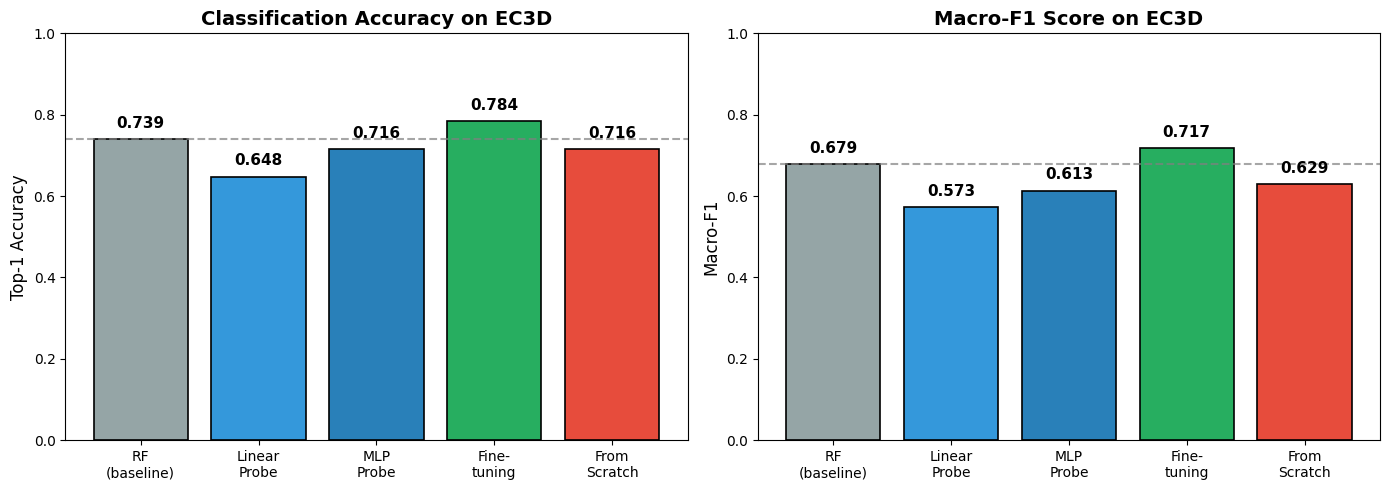


✅ Plot salvato in debug_plots/ec3d_finetuning_comparison_WithoutUnknown.png


In [48]:
# Visualizzazione risultati
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['RF\n(baseline)', 'Linear\nProbe', 'MLP\nProbe', 'Fine-\ntuning', 'From\nScratch']
top1_accs = [0.739, acc_linear, acc_mlp, acc_ft, acc_scratch]
macro_f1s = [0.679, macro_f1_linear, macro_f1_mlp, macro_f1_ft, macro_f1_scratch]
colors = ['#95a5a6', '#3498db', '#2980b9', '#27ae60', '#e74c3c']

# Top-1 Accuracy
ax1 = axes[0]
bars1 = ax1.bar(methods, top1_accs, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_ylabel('Top-1 Accuracy', fontsize=12)
ax1.set_title('Classification Accuracy on EC3D', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.axhline(y=0.739, color='gray', linestyle='--', alpha=0.7, label='RF Baseline')
for bar, val in zip(bars1, top1_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Macro-F1
ax2 = axes[1]
bars2 = ax2.bar(methods, macro_f1s, color=colors, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Macro-F1', fontsize=12)
ax2.set_title('Macro-F1 Score on EC3D', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.axhline(y=0.679, color='gray', linestyle='--', alpha=0.7, label='RF Baseline')
for bar, val in zip(bars2, macro_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(ROOT_DIR / 'debug_plots' / 'ec3d_finetuning_comparison_WithoutUnknown.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot salvato in debug_plots/ec3d_finetuning_comparison_WithoutUnknown.png")


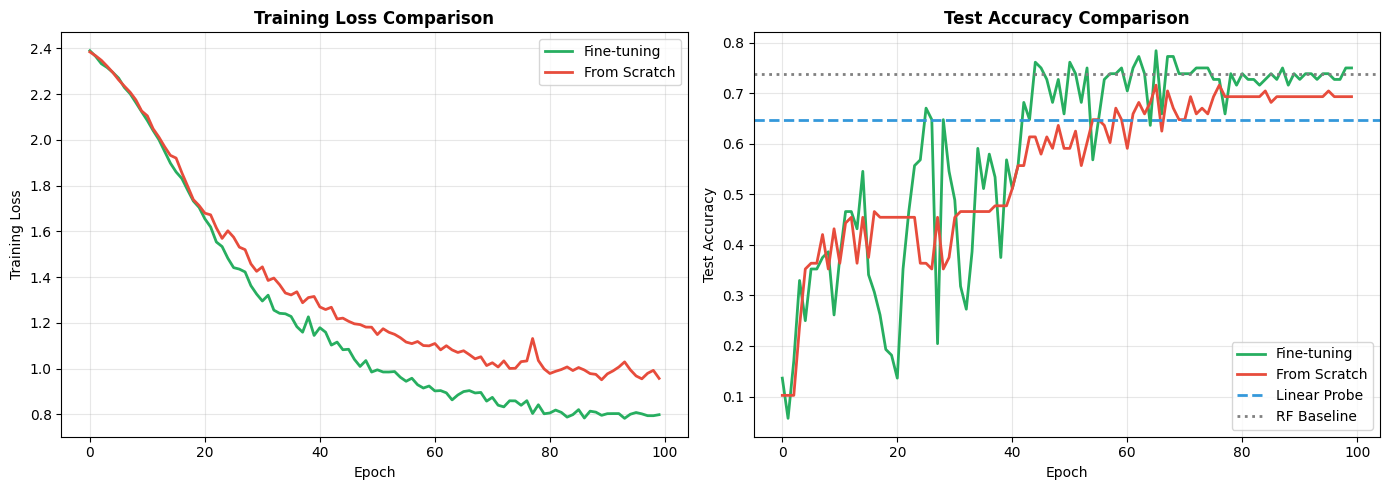

In [49]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1 = axes[0]
ax1.plot(history_ft['train_loss'], label='Fine-tuning', color='#27ae60', linewidth=2)
ax1.plot(history_scratch['train_loss'], label='From Scratch', color='#e74c3c', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Comparison', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2 = axes[1]
ax2.plot(history_ft['test_acc'], label='Fine-tuning', color='#27ae60', linewidth=2)
ax2.plot(history_scratch['test_acc'], label='From Scratch', color='#e74c3c', linewidth=2)
ax2.axhline(y=acc_linear, color='#3498db', linestyle='--', label='Linear Probe', linewidth=2)
ax2.axhline(y=0.739, color='gray', linestyle=':', label='RF Baseline', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Test Accuracy Comparison', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT_DIR / 'debug_plots' / 'ec3d_training_curves__WithoutUnknown.png', dpi=150, bbox_inches='tight')
plt.show()


In [50]:
# Salva risultati in CSV
results_path = ROOT_DIR / 'debug_outputs' / 'ec3d_finetuning_results_WihoutUnknown.csv'
results.to_csv(results_path, index=False)
print(f"✅ Risultati salvati in: {results_path}")

# Classification report fine-tuning
print("\n" + "=" * 70)
print("📋 CLASSIFICATION REPORT - Fine-tuning")
print("=" * 70)
print(classification_report(y_test_ft, y_pred_ft, 
                           target_names=[ID_TO_NAME[i] for i in sorted(np.unique(y_test_ft))]))


✅ Risultati salvati in: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_finetuning_results_WihoutUnknown.csv

📋 CLASSIFICATION REPORT - Fine-tuning
                          precision    recall  f1-score   support

         SQUAT - Correct       0.91      1.00      0.95        10
   SQUAT - Feet too wide       0.83      1.00      0.91         5
    SQUAT - Knees inward       0.00      0.00      0.00         5
  SQUAT - Not low enough       1.00      0.75      0.86         4
    SQUAT - Front bended       0.50      0.86      0.63         7
        LUNGES - Correct       0.52      0.92      0.67        12
 LUNGES - Not low enough       1.00      1.00      1.00        10
LUNGES - Knees pass toes       0.00      0.00      0.00        10
         PLANK - Correct       1.00      0.86      0.92         7
     PLANK - Banana back       0.90      1.00      0.95         9
     PLANK - Rolled back       1.00      1.00      1.00         9

                accuracy           

/home/giov/Scrivania/Tesi/pose-text-feedback-thesis/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/giov/Scrivania/Tesi/pose-text-feedback-thesis/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/giov/Scrivania/Tesi/pose-text-feedback-thesis/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

In [51]:
from sklearn.metrics import classification_report
import json

# Genera il classification report come dizionario
report_dict = classification_report(
    y_test_ft, 
    y_pred_ft, 
    target_names=[ID_TO_NAME[i] for i in sorted(np.unique(y_test_ft))],
    output_dict=True  # Questo restituisce un dict invece di una stringa
)

# Salva in JSON
report_path = ROOT_DIR / 'debug_outputs' / "ec3dfinetuning_classification_report_WithoutUnknown.json"
with open(report_path, 'w') as f:
    json.dump(report_dict, f, indent=2)

print(f"✅ Classification report salvato in: {report_path}")

# Stampa anche a schermo
print("\n" + "=" * 70)
print("📋 CLASSIFICATION REPORT - Fine-tuning")
print("=" * 70)
print(classification_report(y_test_ft, y_pred_ft, 
                           target_names=[ID_TO_NAME[i] for i in sorted(np.unique(y_test_ft))]))

✅ Classification report salvato in: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3dfinetuning_classification_report_WithoutUnknown.json

📋 CLASSIFICATION REPORT - Fine-tuning
                          precision    recall  f1-score   support

         SQUAT - Correct       0.91      1.00      0.95        10
   SQUAT - Feet too wide       0.83      1.00      0.91         5
    SQUAT - Knees inward       0.00      0.00      0.00         5
  SQUAT - Not low enough       1.00      0.75      0.86         4
    SQUAT - Front bended       0.50      0.86      0.63         7
        LUNGES - Correct       0.52      0.92      0.67        12
 LUNGES - Not low enough       1.00      1.00      1.00        10
LUNGES - Knees pass toes       0.00      0.00      0.00        10
         PLANK - Correct       1.00      0.86      0.92         7
     PLANK - Banana back       0.90      1.00      0.95         9
     PLANK - Rolled back       1.00      1.00      1.00         9

        

/home/giov/Scrivania/Tesi/pose-text-feedback-thesis/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/giov/Scrivania/Tesi/pose-text-feedback-thesis/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/giov/Scrivania/Tesi/pose-text-feedback-thesis/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par